<a href="https://colab.research.google.com/github/deepkaur09/airport-surface-safety-system/blob/main/AS_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install ultralytics opencv-python-headless matplotlib numpy -q
print("All libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.4 MB/s eta 0:00:00
All libraries installed!


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("✅ All libraries ready — Airport AI setup complete!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
OpenCV version: 5.0.0
NumPy version: 2.1.3
✅ All libraries ready — Airport AI setup complete!


In [7]:
import cv2

video_path = "/content/drive/MyDrive/AirportVideo/airport.mp4"
cap = cv2.VideoCapture(video_path)

print("Video opened:", cap.isOpened())
print("Total frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("FPS:", cap.get(cv2.CAP_PROP_FPS))
print("Width:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Height:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

Video opened: True
Total frames: 387
FPS: 30.0
Width: 1280
Height: 720


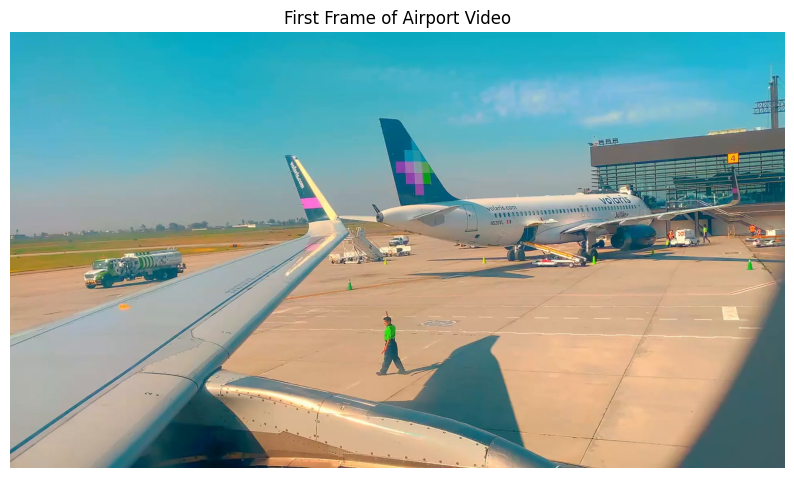

In [8]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")

# Read the first frame
ret, frame = cap.read()

# Convert color from BGR to RGB for display
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Show it
plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.title("First Frame of Airport Video")
plt.axis("off")
plt.show()

cap.release()


0: 384x640 1 person, 2 airplanes, 1 truck, 470.3ms
Speed: 56.9ms preprocess, 470.3ms inference, 46.5ms postprocess per image at shape (1, 3, 384, 640)


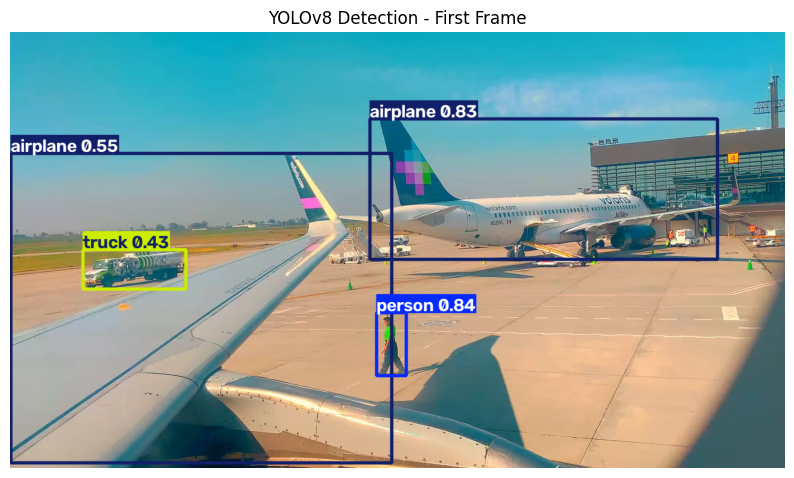

In [9]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLOv8 model (downloads automatically, small and fast)
model = YOLO("yolov8n.pt")

# Read one frame from your video
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
ret, frame = cap.read()
cap.release()

# Run YOLO detection on that frame
results = model(frame)

# Show the frame with detections drawn on it
annotated_frame = results[0].plot()
annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(annotated_frame_rgb)
plt.title("YOLOv8 Detection - First Frame")
plt.axis("off")
plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
import os

# Load model
model = YOLO("yolov8n.pt")

# Open video
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Setup output video writer
output_path = "/content/drive/MyDrive/AirportVideo/airport_detected.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

print(f"Processing {total_frames} frames...")

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO on each frame
    results = model(frame, verbose=False)
    annotated_frame = results[0].plot()

    # Write to output video
    out.write(annotated_frame)
    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
out.release()
print(f"\nDone! Saved to your Drive as airport_detected.mp4")

In [ ]:
from ultralytics import YOLO
import cv2

# Load YOLOv8 model with tracking
model = YOLO("yolov8n.pt")

# Open video
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")

# Setup output video
output_path = "/content/drive/MyDrive/AirportVideo/airport_tracked.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_count = 0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Starting tracking...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # track=True is the only difference from before!
    results = model.track(frame, persist=True, verbose=False)
    annotated_frame = results[0].plot()

    out.write(annotated_frame)
    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
out.release()
print(f"\nDone! Saved as airport_tracked.mp4")

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np

model = YOLO("yolov8n.pt")

cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
output_path = "/content/drive/MyDrive/AirportVideo/airport_smart_v2.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

previous_positions = {}
DANGER_DISTANCE = 150

def get_center(box):
    x1, y1, x2, y2 = box
    return (int((x1+x2)/2), int((y1+y2)/2))

def get_speed(obj_id, center, prev_positions):
    if obj_id in prev_positions:
        px, py = prev_positions[obj_id]
        return np.sqrt((center[0]-px)**2 + (center[1]-py)**2)
    return 0

frame_count = 0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Processing smart detection v2...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.35, verbose=False)

    current_positions = {}
    objects = []

    if results[0].boxes.id is not None:
        for box, obj_id, cls, conf in zip(
            results[0].boxes.xyxy,
            results[0].boxes.id,
            results[0].boxes.cls,
            results[0].boxes.conf
        ):
            obj_id = int(obj_id)
            center = get_center(box.tolist())
            speed = get_speed(obj_id, center, previous_positions)
            label = model.names[int(cls)]

            current_positions[obj_id] = center
            objects.append({
                "id": obj_id,
                "center": center,
                "speed": speed,
                "label": label,
                "box": box.tolist()
            })

            # Draw box and label
            x1,y1,x2,y2 = [int(v) for v in box.tolist()]
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(frame, f"id:{obj_id} {label} {conf:.2f}",
                       (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    # Check for dangers between object pairs
    for i in range(len(objects)):
        for j in range(i+1, len(objects)):
            o1, o2 = objects[i], objects[j]
            dist = np.sqrt((o1["center"][0]-o2["center"][0])**2 +
                          (o1["center"][1]-o2["center"][1])**2)

            both_moving = o1["speed"] > 3 and o2["speed"] > 3
            one_moving = o1["speed"] > 3 or o2["speed"] > 3

            # Midpoint between the two objects
            mid_x = (o1["center"][0] + o2["center"][0]) // 2
            mid_y = (o1["center"][1] + o2["center"][1]) // 2

            if dist < DANGER_DISTANCE:
                if both_moving:
                    # RED alert — two moving objects close together
                    cv2.putText(frame, f"DANGER: {o1['label']} & {o2['label']}!",
                               (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)
                    cv2.circle(frame, (mid_x, mid_y), 60, (0,0,255), 3)

                elif one_moving:
                    # ORANGE warning — one moving one stationary
                    cv2.putText(frame, f"WARNING: {o1['label']} near {o2['label']}",
                               (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,165,255), 2)
                    cv2.circle(frame, (mid_x, mid_y), 60, (0,165,255), 3)

    previous_positions = current_positions
    out.write(frame)
    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
out.release()
print(f"\nDone! Saved as airport_smart_v2.mp4")

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from collections import deque

model = YOLO("yolov8n.pt")

cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
output_path = "/content/drive/MyDrive/AirportVideo/airport_trajectory.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Store last 10 positions for each object to predict trajectory
position_history = {}
HISTORY_LENGTH = 10
DANGER_DISTANCE = 150

def get_center(box):
    x1, y1, x2, y2 = box
    return (int((x1+x2)/2), int((y1+y2)/2))

def predict_future_position(history, steps=15):
    if len(history) < 2:
        return None
    # Calculate average movement direction from last few positions
    dx = history[-1][0] - history[-2][0]
    dy = history[-1][1] - history[-2][1]
    # Predict where object will be in `steps` frames
    future_x = int(history[-1][0] + dx * steps)
    future_y = int(history[-1][1] + dy * steps)
    return (future_x, future_y)

frame_count = 0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Processing trajectory prediction...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.35, verbose=False)

    objects = []

    if results[0].boxes.id is not None:
        for box, obj_id, cls, conf in zip(
            results[0].boxes.xyxy,
            results[0].boxes.id,
            results[0].boxes.cls,
            results[0].boxes.conf
        ):
            obj_id = int(obj_id)
            center = get_center(box.tolist())
            label = model.names[int(cls)]

            # Update position history for this object
            if obj_id not in position_history:
                position_history[obj_id] = deque(maxlen=HISTORY_LENGTH)
            position_history[obj_id].append(center)

            # Draw box and label
            x1,y1,x2,y2 = [int(v) for v in box.tolist()]
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(frame, f"id:{obj_id} {label}",
                       (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

            # Draw trail — where object has been
            history = list(position_history[obj_id])
            for k in range(1, len(history)):
                cv2.circle(frame, history[k], 3, (255,255,0), -1)

            # Draw predicted future position
            future = predict_future_position(position_history[obj_id])
            if future:
                fx, fy = future
                # Make sure prediction stays within frame
                fx = max(0, min(fx, width-1))
                fy = max(0, min(fy, height-1))
                cv2.circle(frame, (fx, fy), 8, (0,0,255), -1)
                cv2.arrowedLine(frame, center, (fx,fy), (0,0,255), 2)
                cv2.putText(frame, "predicted",
                           (fx+5, fy), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1)

            objects.append({
                "id": obj_id,
                "center": center,
                "future": future,
                "label": label
            })

    # Check if any two predicted positions will collide
    for i in range(len(objects)):
        for j in range(i+1, len(objects)):
            o1, o2 = objects[i], objects[j]
            if o1["future"] and o2["future"]:
                future_dist = np.sqrt(
                    (o1["future"][0]-o2["future"][0])**2 +
                    (o1["future"][1]-o2["future"][1])**2
                )
                if future_dist < DANGER_DISTANCE:
                    cv2.putText(frame,
                               f"COLLISION PREDICTED: {o1['label']} & {o2['label']}",
                               (50, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

    out.write(frame)
    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
out.release()
print(f"\nDone! Saved as airport_trajectory.mp4")

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from collections import deque
import csv

model = YOLO("yolov8n.pt")

cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

position_history = {}
HISTORY_LENGTH = 10
DANGER_DISTANCE = 150

def get_center(box):
    x1, y1, x2, y2 = box
    return (int((x1+x2)/2), int((y1+y2)/2))

def get_speed(obj_id, center, history):
    if obj_id in history and len(history[obj_id]) >= 2:
        prev = history[obj_id][-2]
        return np.sqrt((center[0]-prev[0])**2 + (center[1]-prev[1])**2)
    return 0

def predict_future_position(history, steps=15):
    if len(history) < 2:
        return None
    dx = history[-1][0] - history[-2][0]
    dy = history[-1][1] - history[-2][1]
    return (int(history[-1][0] + dx * steps), int(history[-1][1] + dy * steps))

# Create CSV file
csv_path = "/content/drive/MyDrive/AirportVideo/safety_alerts.csv"
csvfile = open(csv_path, "w", newline="")
writer = csv.writer(csvfile)
writer.writerow(["Frame", "Time(s)", "Object1_ID", "Object1_Type",
                 "Object2_ID", "Object2_Type", "Alert_Type",
                 "Distance(px)", "Severity"])

frame_count = 0
total_alerts = 0
print("Generating safety alert report...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.35, verbose=False)
    objects = []

    if results[0].boxes.id is not None:
        for box, obj_id, cls, conf in zip(
            results[0].boxes.xyxy,
            results[0].boxes.id,
            results[0].boxes.cls,
            results[0].boxes.conf
        ):
            obj_id = int(obj_id)
            center = get_center(box.tolist())
            label = model.names[int(cls)]

            if obj_id not in position_history:
                position_history[obj_id] = deque(maxlen=HISTORY_LENGTH)
            position_history[obj_id].append(center)

            speed = get_speed(obj_id, center, position_history)
            future = predict_future_position(position_history[obj_id])

            objects.append({
                "id": obj_id,
                "center": center,
                "speed": speed,
                "future": future,
                "label": label
            })

    # Check every pair of objects
    for i in range(len(objects)):
        for j in range(i+1, len(objects)):
            o1, o2 = objects[i], objects[j]

            dist = np.sqrt((o1["center"][0]-o2["center"][0])**2 +
                          (o1["center"][1]-o2["center"][1])**2)

            time_sec = round(frame_count / fps, 2)
            both_moving = o1["speed"] > 3 and o2["speed"] > 3
            one_moving = o1["speed"] > 3 or o2["speed"] > 3

            # Check current proximity alerts
            if dist < DANGER_DISTANCE:
                if both_moving:
                    writer.writerow([frame_count, time_sec,
                                    o1["id"], o1["label"],
                                    o2["id"], o2["label"],
                                    "DANGER", round(dist), "HIGH"])
                    total_alerts += 1
                elif one_moving:
                    writer.writerow([frame_count, time_sec,
                                    o1["id"], o1["label"],
                                    o2["id"], o2["label"],
                                    "WARNING", round(dist), "MEDIUM"])
                    total_alerts += 1

            # Check predicted collision
            if o1["future"] and o2["future"]:
                future_dist = np.sqrt(
                    (o1["future"][0]-o2["future"][0])**2 +
                    (o1["future"][1]-o2["future"][1])**2)
                if future_dist < DANGER_DISTANCE:
                    writer.writerow([frame_count, time_sec,
                                    o1["id"], o1["label"],
                                    o2["id"], o2["label"],
                                    "COLLISION PREDICTED",
                                    round(future_dist), "CRITICAL"])
                    total_alerts += 1

    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
csvfile.close()
print(f"\nDone! Total alerts logged: {total_alerts}")
print(f"Report saved to: safety_alerts.csv")

Airport Map and Coordinate Calibration

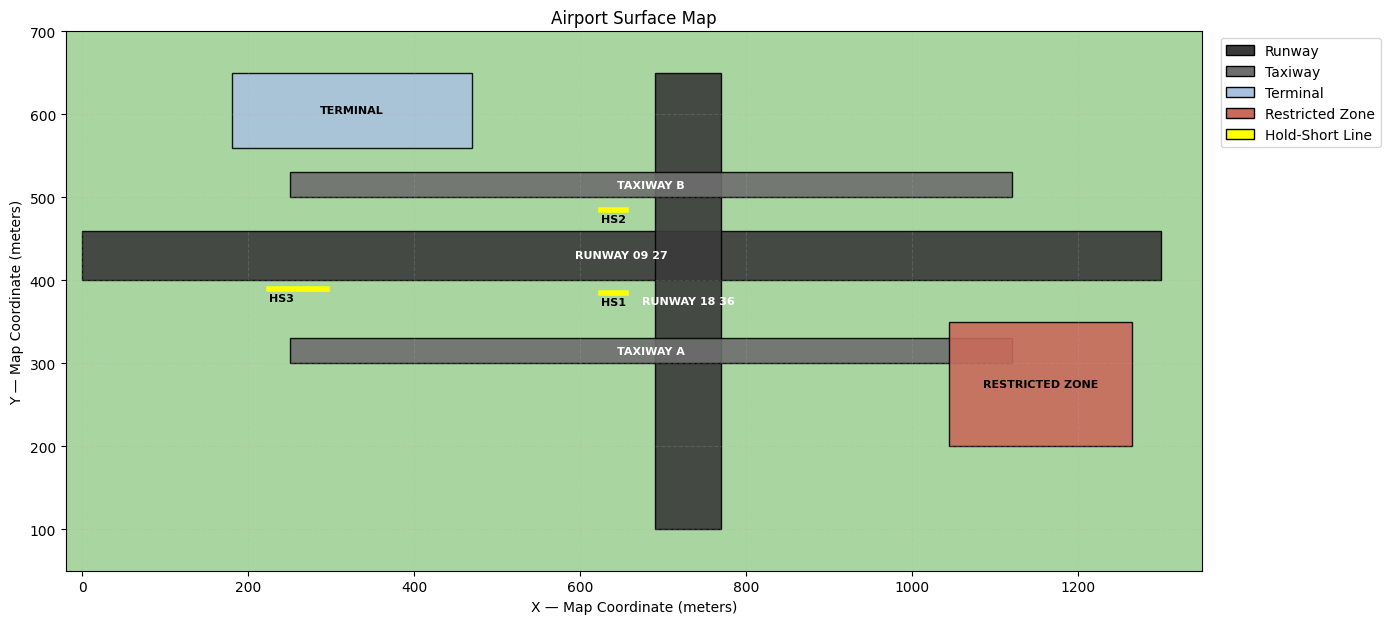

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch
import numpy as np

# ---------------------------------------------------------
# AIRPORT MAP DEFINITION
# All coordinates in meters, as (x, y) polygon corners
# ---------------------------------------------------------

airport_map = {
    "runway_09_27": {
        "coords": [(0, 400), (1300, 400), (1300, 460), (0, 460)],
        "color": "#3a3a3a",
        "type": "runway"
    },
    "runway_18_36": {
        "coords": [(690, 100), (770, 100), (770, 650), (690, 650)],
        "color": "#3a3a3a",
        "type": "runway"
    },
    "taxiway_A": {
        "coords": [(250, 300), (1120, 300), (1120, 330), (250, 330)],
        "color": "#6e6e6e",
        "type": "taxiway"
    },
    "taxiway_B": {
        "coords": [(250, 500), (1120, 500), (1120, 530), (250, 530)],
        "color": "#6e6e6e",
        "type": "taxiway"
    },
    "terminal": {
        "coords": [(180, 560), (470, 560), (470, 650), (180, 650)],
        "color": "#a9c1de",
        "type": "building"
    },
    "restricted_zone": {
        "coords": [(1045, 200), (1265, 200), (1265, 350), (1045, 350)],
        "color": "#c96a5a",
        "type": "restricted"
    }
}

# Hold-short lines (as short line segments, not polygons)
hold_short_lines = {
    "HS1": [(625, 385), (655, 385)],   # near runway 09/27 crossing taxiway A
    "HS2": [(625, 485), (655, 485)],   # near taxiway B crossing runway
    "HS3": [(225, 390), (295, 390)]    # left-side crossing marker
}

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

def draw_airport_map(airport_map, hold_short_lines):
    fig, ax = plt.subplots(figsize=(14, 8))

    # background grass
    ax.set_facecolor("#a9d6a0")

    for name, zone in airport_map.items():
        poly = Polygon(zone["coords"], closed=True,
                        facecolor=zone["color"], edgecolor="black",
                        linewidth=1, alpha=0.9)
        ax.add_patch(poly)
        cx = np.mean([p[0] for p in zone["coords"]])
        cy = np.mean([p[1] for p in zone["coords"]])
        label_color = "white" if zone["type"] in ["runway", "taxiway"] else "black"
        ax.text(cx, cy, name.replace("_", " ").upper(), ha="center", va="center",
                 fontsize=8, weight="bold", color=label_color)

    # hold-short lines
    for hs_name, (p1, p2) in hold_short_lines.items():
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="yellow", linewidth=4)
        ax.text(p1[0], p1[1]-15, hs_name, fontsize=8, weight="bold", color="black")

    # legend
    legend_elements = [
        Patch(facecolor="#3a3a3a", edgecolor="black", label="Runway"),
        Patch(facecolor="#6e6e6e", edgecolor="black", label="Taxiway"),
        Patch(facecolor="#a9c1de", edgecolor="black", label="Terminal"),
        Patch(facecolor="#c96a5a", edgecolor="black", label="Restricted Zone"),
        Patch(facecolor="yellow", edgecolor="black", label="Hold-Short Line"),
    ]
    ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1))

    ax.set_xlim(-20, 1350)
    ax.set_ylim(50, 700)
    ax.set_xlabel("X — Map Coordinate (meters)")
    ax.set_ylabel("Y — Map Coordinate (meters)")
    ax.set_title("Airport Surface Map")
    ax.set_aspect("equal")
    plt.grid(True, linestyle="--", alpha=0.2)
    plt.tight_layout()
    plt.show()

draw_airport_map(airport_map, hold_short_lines)

Frame size: width=1280, height=720


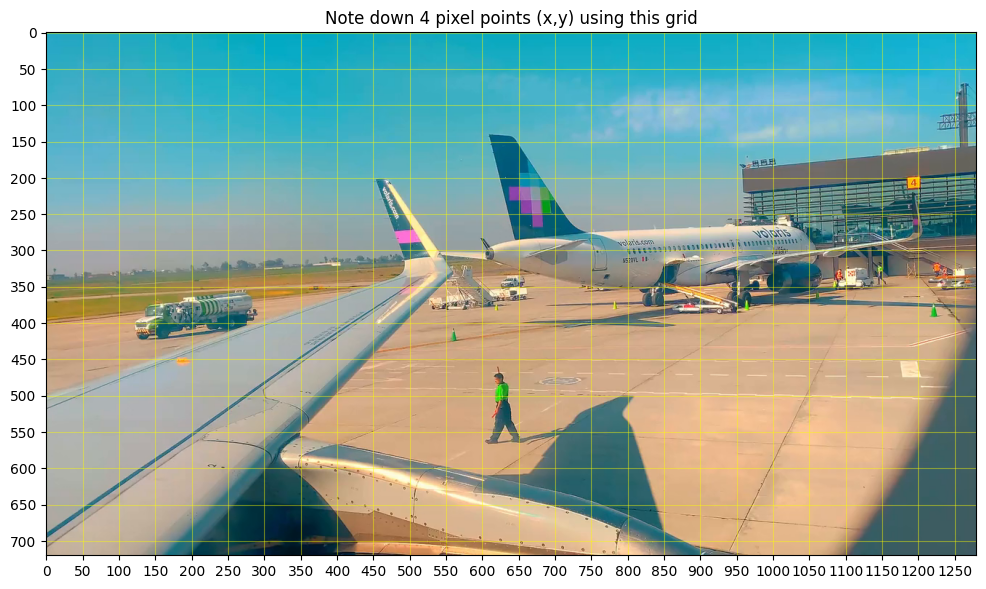

In [18]:
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
ret, frame = cap.read()
cap.release()

if not ret:
    print("Failed to read frame — check your video path")
else:
    h, w = frame.shape[:2]
    print(f"Frame size: width={w}, height={h}")

    plt.figure(figsize=(12,7))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.xticks(np.arange(0, w, 50))
    plt.yticks(np.arange(0, h, 50))
    plt.grid(True, color='yellow', alpha=0.4)
    plt.title("Note down 4 pixel points (x,y) using this grid")
    plt.show()

In [19]:
# Replace these with the actual coordinates you read off the grid above
x1, y1 = 50, 400     # bottom-left
x2, y2 = 600, 400    # bottom-right
x3, y3 = 550, 100    # top-right
x4, y4 = 100, 100    # top-left

image_points = np.array([[x1,y1],[x2,y2],[x3,y3],[x4,y4]], dtype=np.float32)

# These should match the corners of your map's runway rectangle
map_points = np.array([[0,0],[200,0],[200,30],[0,30]], dtype=np.float32)

H, status = cv2.findHomography(image_points, map_points)
print("Homography matrix:\n", H)

Homography matrix:
 [[       0.48        0.08         -56]
 [          0      -0.108        43.2]
 [          0      0.0008           1]]


In [20]:
def pixel_to_map(point, H):
    p = np.array([[point]], dtype=np.float32)
    mapped = cv2.perspectiveTransform(p, H)
    return tuple(mapped[0][0])

# Quick test — should map close to (0,0) since it's your bottom-left calibration point
test_point = (x1, y1)
print("Mapped point:", pixel_to_map(test_point, H))

Mapped point: (np.float32(-1.6148698e-14), np.float32(0.0))
